# DAF-14: Lag, Rolling, Calendar Features, and Selection

## The story

Asha's simple persistence rule knows today's PM2.5 and assumes tomorrow will look the same. That is useful, but it cannot see whether pollution has been rising for a week, whether the current day is unusually high compared with yesterday, or whether the season changes the pattern.

DAF-14 teaches the model to describe recent history, change, volatility, season, and known events. We will add one feature family at a time so we can measure what each family actually contributes.

The second half of the ticket is feature selection: deciding which features to keep using training data only, without allowing test rows to influence the choice.

## What this ticket is about

A feature is a number the model can use as an input. DAF-07 used five basic inputs. DAF-14 adds richer descriptions of the same prediction moment:

```text
Today's PM2.5 history + recent patterns + calendar context
                         |
                         v
              a better description of tomorrow's context
                         |
                         v
                 next-day PM2.5 prediction
```
The important rule from DAF-13 still applies: every new feature must be knowable at 18:00 today. A clever feature that uses future information is not a valid feature.

## The 18:00 boundary still controls everything

Suppose the prediction is made at 18:00 on March 10 for March 11.

```text
Allowed at 18:00 on March 10       Not allowed
-----------------------------       ----------
pm25_until_17 on March 10           full March 10 mean
March 9 full-day PM2.5              March 11 actual weather
last 7 completed days               a feature learned from test rows
March calendar information          a label based on future bad days
```
Rolling calculations must stop at yesterday. If a rolling mean includes today's unfinished full-day value, the model sees information that is not available when Asha makes the prediction.

## Feature families we will investigate

| Family | Examples | What it helps the model see |
|---|---|---|
| Lags | `lag_1`, `lag_2`, `lag_7` | Yesterday's value, short memory, weekly rhythm |
| Rolling | 3/7/14-day mean, 7-day std, 7-day max | Level, trend, volatility, recent extremes |
| Change | `pm25_until_17 - lag_1` | Whether today is worse or better than yesterday |
| Calendar | Month sin/cos, day of week, day of year | Season and repeating calendar patterns |
| Events | Festival flag, crop-burning season flag | Known events that may change pollution conditions |

We will not add all families at once. One family per experiment makes the experiment log explainable: we can see which change helped, which did nothing, and which made the model worse.

## Why month needs sin and cos

If month is stored as the number 1 to 12, a linear model treats December and January as far apart:

```text
January = 1  --------------------------------  December = 12
                 treated as very far apart
```
But the calendar is circular: December is next to January. Sine and cosine give the model two coordinates on a circle, so the end and beginning of the year are close together.

```text
month_sin = sin(2*pi*month/12)
month_cos = cos(2*pi*month/12)
```
DAF-14 will explain and test this rather than silently replacing the original `month` feature.

## Why feature selection must use training rows only

Feature selection asks: which inputs are useful enough to keep? That question is part of learning. If we use all rows, including the test period, the test data influences the feature choice before the final score.

```text
WRONG                                      RIGHT
all rows -> choose features -> score     train rows -> choose features
       test rows influenced choice              |
       = leaked evaluation                      v
                                         untouched test rows -> score
```
Two acceptable approaches in this ticket are a selector inside the model pipeline, such as `SelectKBest`, or permutation importance calculated on a validation slice at the end of the training period. The test rows must remain untouched until the final evaluation.

## Journey through DAF-14

```text
1. Add and test feature families in the feature module
          |
          v
2. Add one family to Ridge and score it
          |
          v
3. Repeat for lags, rolling, change, calendar, and events
          |
          v
4. Select features using training rows only
          |
          v
5. Look up festival dates and record their source
          |
          v
6. Name and record the final feature set
```
Every experiment keeps the same chronological cut date and scoring method so the effect of each family is visible in `reports/experiments.csv`.

## What this ticket will not do

```text
This ticket does:                       This ticket does not:
- add richer history features             - add every family at once
- encode calendar cycles                  - use test rows for selection
- test known events                       - use future outcomes to make flags
- measure each family                     - silently change the cut date
- name a final feature set               - claim a feature helped without scoring it
```
The feature contract from DAF-13 remains the guardrail. A festival flag is valid because the calendar date is known in advance. A flag created from days that later turned out to have bad air would be leakage.

## Tiny Delhi example before Step 1

Here is a made-up 10-day PM2.5 table. The point is to see the transformation, not to model Delhi yet.

```text
past PM2.5 values
        |
        +--> lag_1: yesterday
        +--> mean_3: previous 3 complete days
        +--> change: today so far - yesterday
        +--> month: calendar position
        +--> target: tomorrow's PM2.5
```

The next cell creates the table and draws the transformation.

,pm25_mean,pm25_until_17,lag_1,mean_3,change,month,target
date,,,,,,,
2026-03-01,80,78,NaN,NaN,NaN,3,95.0
2026-03-02,95,92,80.0,NaN,12.0,3,110.0
2026-03-03,110,108,95.0,NaN,13.0,3,90.0
2026-03-04,90,88,110.0,95.0,-22.0,3,120.0
2026-03-05,120,115,90.0,98.3,25.0,3,140.0
2026-03-06,140,135,120.0,106.7,15.0,3,130.0
2026-03-07,130,125,140.0,116.7,-15.0,3,100.0
2026-03-08,100,97,130.0,130.0,-33.0,3,85.0
2026-03-09,85,83,100.0,123.3,-17.0,3,105.0


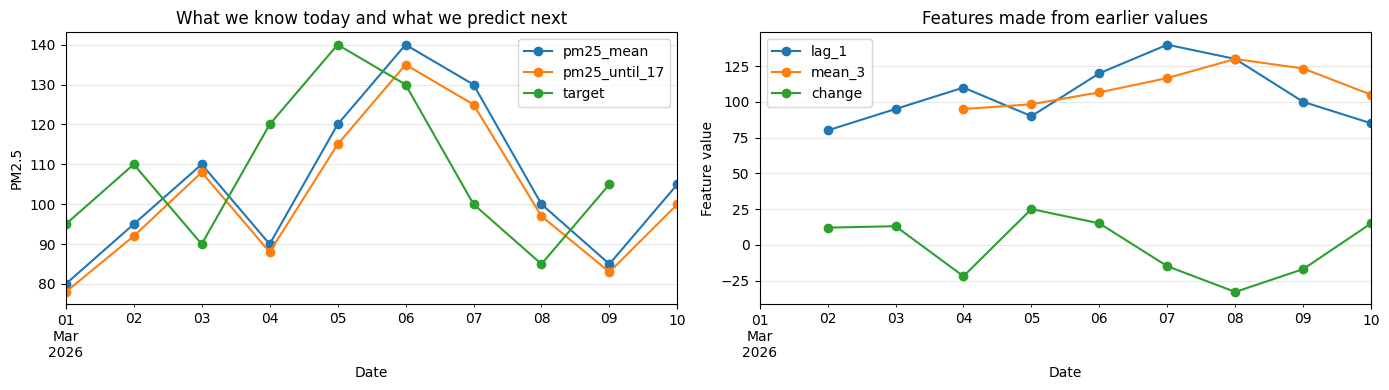

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

example = pd.DataFrame(
    {
        "date": pd.date_range("2026-03-01", periods=10, freq="D"),
        "pm25_mean": [80, 95, 110, 90, 120, 140, 130, 100, 85, 105],
        "pm25_until_17": [78, 92, 108, 88, 115, 135, 125, 97, 83, 100],
    }
).set_index("date")

yesterday = example["pm25_mean"].shift(1)
example["lag_1"] = yesterday
example["mean_3"] = yesterday.rolling(3).mean()
example["change"] = example["pm25_until_17"] - example["lag_1"]
example["month"] = example.index.month
example["target"] = example["pm25_mean"].shift(-1)

display(example.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
example[["pm25_mean", "pm25_until_17", "target"]].plot(
    ax=axes[0],
    marker="o",
    title="What we know today and what we predict next",
)
axes[0].set_ylabel("PM2.5")
axes[0].set_xlabel("Date")
axes[0].grid(alpha=0.3)

example[["lag_1", "mean_3", "change"]].plot(
    ax=axes[1],
    marker="o",
    title="Features made from earlier values",
)
axes[1].set_ylabel("Feature value")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

fig.tight_layout()
display(fig)
plt.close(fig)

### Read the example

- March 2 uses March 1 as `lag_1`.
- March 4's `mean_3` uses March 1, 2, and 3, not March 4.
- March 5's `target` is March 6's PM2.5 value.
- The first rows have missing history by design; the last row has no tomorrow target yet.

# Step 1 — Add and test the feature families

## 🎬 How we got here

DAF-07 gave the model five basic inputs. DAF-13 checked that each input is knowable at 18:00 and wrote the feature contract. The model still has one weakness: it mostly sees today's PM2.5 and a few simple summaries.

Persistence can say:

```text
"Tomorrow will look like today."
```

But Asha needs the model to notice things persistence cannot see: pollution rising for several days, a sudden change from yesterday, a repeating seasonal pattern, or a known festival date.

## 😖 The problem

A single PM2.5 value does not tell the whole story. These two situations can have the same value today but different futures:

```text
Situation A                         Situation B
Today = 100                         Today = 100
Previous days: 60, 70, 80           Previous days: 140, 130, 120
Pollution is rising                  Pollution is falling
```

A model needs features that describe the **shape of recent history**, not only today's number.

There is also a timing trap. At 18:00, today's full-day mean is not finished. A rolling feature that accidentally includes today's full-day value would use information Asha does not have.

## 💡 The idea

Add one family at a time. Each family gives the model one new way to see the same prediction moment:

```text
Recent PM2.5 table
        |
        +--> Lags       What was the value 1, 2, or 7 days ago?
        +--> Rolling    What was the recent level, spread, or maximum?
        +--> Change     Is today so far higher or lower than yesterday?
        +--> Calendar   Where are we in the repeating year/week cycle?
        +--> Events     Is a known festival or season flag active?
        |
        v
A richer description of tomorrow's context
```

The backend analogy: these are observability signals for a service. One latency number is less useful than latency history, recent average, change from baseline, weekly pattern, and a known deployment event. The analogy breaks down because PM2.5 is a physical process, not a software service, but both need context around the current value.

## 🔍 What each family solves

### 1. Lags: memory

`lag_1`, `lag_2`, and `lag_7` answer: *What was PM2.5 on earlier completed days?* They expose yesterday's value, short memory, and weekly rhythm.

### 2. Rolling features: recent context

`mean_3`, `mean_7`, and `mean_14` describe recent level. `std_7` describes recent volatility. `max_7` shows whether a high episode occurred recently.

Every rolling feature uses values up to **yesterday**, never today's unfinished full-day value.

### 3. Change: direction

`pm25_change = pm25_until_17 - lag_1` answers: *Is today's air already worse or better than yesterday's complete day?*

### 4. Calendar: repeating patterns

Month and day-of-year are not ordinary straight-line numbers. Cyclic sine/cosine features tell the model that December and January are neighbours, not opposite ends of a ruler.

### 5. Events: known context

A festival or crop-burning season flag can be valid because the calendar is known before prediction time. A flag created from days that later turned out to have bad air would be leakage and is not allowed.

## What breaks if we skip the timing rule?

```text
Wrong rolling feature                  Correct rolling feature
---------------------                  ----------------------
March 10 row includes March 10 mean   March 10 row ends at March 9
Model sees an unfinished day           Model uses completed history only
Test score looks cleaner                Production timing remains honest
```

If we add every family at once, we create a second problem: even if the score changes, we will not know which family caused the change. That is why Step 2 will score one family at a time with the same cut date.

## What Step 1 will prove

- `clean.py` owns the shared feature recipes used by notebooks and the future service.
- Each family has a focused test using a tiny hand-built table.
- Lags look backward by the correct number of completed days.
- Rolling statistics stop at yesterday.
- Calendar features follow the cycle.
- Event flags use known dates, not future outcomes.
- The DAF-13 feature contract lists the new feature names and timing rules.

The next code cell imports the shared implementation and shows the feature families on our 10-row example. The tests run separately in `tests/test_clean.py`.

In [2]:
from pathlib import Path

from delhi_air.clean import add_feature_families

feature_example = add_feature_families(
    example,
    festival_dates=["2026-03-05"],
)

feature_columns = [
    "pm25_mean",
    "pm25_until_17",
    "lag_1",
    "lag_2",
    "lag_7",
    "mean_3",
    "mean_7",
    "mean_14",
    "std_7",
    "max_7",
    "pm25_change",
    "month_sin",
    "month_cos",
    "day_of_week",
    "festival_flag",
    "crop_burning_season_flag",
]
display(feature_example[feature_columns].round(2))

contract_path = Path.cwd().parent / "docs/feature_contract.md"
if not contract_path.is_file():
    contract_path = next(Path.cwd().parents).joinpath("docs/feature_contract.md")

contract_text = contract_path.read_text(encoding="utf-8")
if "## DAF-14 additions" not in contract_text:
    contract_text += """

## DAF-14 additions

These feature families are built by `src/delhi_air/clean.py` and tested in `tests/test_clean.py`.

| Family | Features | Timing rule |
|---|---|---|
| Lags | `lag_1`, `lag_2`, `lag_7` | completed days only |
| Rolling | `mean_3`, `mean_7`, `mean_14`, `std_7`, `max_7` | completed days only; ends yesterday |
| Change | `pm25_change` | today 00:00-17:00 minus yesterday's complete-day mean |
| Calendar | `month_sin`, `month_cos`, `day_of_week`, `day_of_year_sin`, `day_of_year_cos` | known from the prediction date |
| Events | `festival_flag`, `crop_burning_season_flag` | known calendar rules only |
"""
    contract_path.write_text(contract_text, encoding="utf-8")
    print(f"Updated {contract_path}")
else:
    print(f"DAF-14 additions already present in {contract_path}")

,pm25_mean,pm25_until_17,lag_1,lag_2,lag_7,mean_3,mean_7,mean_14,std_7,max_7,pm25_change,month_sin,month_cos,day_of_week,festival_flag,crop_burning_season_flag
date,,,,,,,,,,,,,,,,
2026-03-01,80,78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,6,0,0
2026-03-02,95,92,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,1.0,0.0,0,0,0
2026-03-03,110,108,95.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,1.0,0.0,1,0,0
2026-03-04,90,88,110.0,95.0,NaN,95.00,NaN,NaN,NaN,NaN,-22.0,1.0,0.0,2,0,0
2026-03-05,120,115,90.0,110.0,NaN,98.33,NaN,NaN,NaN,NaN,25.0,1.0,0.0,3,1,0
2026-03-06,140,135,120.0,90.0,NaN,106.67,NaN,NaN,NaN,NaN,15.0,1.0,0.0,4,0,0
2026-03-07,130,125,140.0,120.0,NaN,116.67,NaN,NaN,NaN,NaN,-15.0,1.0,0.0,5,0,0
2026-03-08,100,97,130.0,140.0,80.0,130.00,109.29,NaN,20.43,140.0,-33.0,1.0,0.0,6,0,0
2026-03-09,85,83,100.0,130.0,95.0,123.33,112.14,NaN,17.29,140.0,-17.0,1.0,0.0,0,0,0


DAF-14 additions already present in /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/docs/feature_contract.md


## Before Step 2

Step 1 added and tested the shared feature families. Now we will add the first family to the model one at a time, starting with lags.

# Step 2 — Add the lag family and score it

## 🎬 How we got here

The DAF-13 baseline already uses `pm25_until_17`, `lag_1`, `mean_3`, `mean_7`, and `month`. Step 1 proved that the shared feature module can safely create additional families.

## 😖 The problem

`lag_1` tells us yesterday's PM2.5, but it cannot show a weekly rhythm. Two days may have the same yesterday value while their seven-day histories are very different.

```text
DAF-07 baseline       DAF-14 lag experiment
lag_1                  lag_1 + lag_2 + lag_7
                       |
                       +--> short memory
                       +--> weekly rhythm
```

## 💡 The idea

Add only `lag_2` and `lag_7` because `lag_1` is already in the baseline. Keep every other choice unchanged:

```text
Same table + same cut date + same Ridge pipeline
                         |
              +----------+----------+
              |                     |
        DAF-13 baseline       DAF-14 lag family
        five features         five + lag_2 + lag_7
              |                     |
              +----------+----------+
                         |
                    compare MAE
                    and recall
```

If the score changes, we can attribute that change to the lag family rather than to a new model or a different test period.

## 🔍 What this actually is

This is the first **family-level experiment**. The new lag values use completed days only, so they are knowable at 18:00. The test rows remain untouched until scoring.

### 🤔 Before you run the code

Which lag should help with a weekly rhythm more directly: `lag_2` or `lag_7`? Predict first, then compare the measured result.

In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from delhi_air.clean import add_lag_features

project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "18_Projects/01_Delhi_Air_Forecast/data/interim/daily_17.csv").is_file()
        or (candidate / "data/interim/daily_17.csv").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find data/interim/daily_17.csv from this notebook's working directory.")

if (project_root / "data/interim/daily_17.csv").is_file():
    data_root = project_root / "data"
else:
    data_root = project_root / "18_Projects/01_Delhi_Air_Forecast/data"

cut_date = pd.Timestamp("2026-03-01")
poor_threshold = 91
daily = pd.read_csv(
    data_root / "interim/daily_17.csv",
    parse_dates=["date"],
    index_col="date",
)
if daily.index.tz is not None:
    daily.index = daily.index.tz_convert("Asia/Kolkata").tz_localize(None)
daily.index = daily.index.normalize()

daily_with_lags = add_lag_features(daily)
yesterday = daily["pm25_mean"].shift(1)
lag_features = pd.DataFrame(index=daily.index)
lag_features["pm25_until_17"] = daily["pm25_until_17"]
lag_features["lag_1"] = daily_with_lags["lag_1"]
lag_features["mean_3"] = yesterday.rolling(3).mean()
lag_features["mean_7"] = yesterday.rolling(7).mean()
lag_features["month"] = daily.index.month
lag_features["lag_2"] = daily_with_lags["lag_2"]
lag_features["lag_7"] = daily_with_lags["lag_7"]
lag_features["target"] = daily["target"]

feature_names = [
    "pm25_until_17",
    "lag_1",
    "mean_3",
    "mean_7",
    "month",
    "lag_2",
    "lag_7",
]
model_table = lag_features.dropna(subset=feature_names + ["target"])
train = model_table.loc[model_table.index < cut_date]
test = model_table.loc[model_table.index >= cut_date]

assert np.isfinite(train[feature_names].to_numpy()).all()
assert np.isfinite(test[feature_names].to_numpy()).all()

pipe = Pipeline(
    [
        ("scale", StandardScaler()),
        ("model", Ridge(alpha=1.0, solver="lsqr")),
    ]
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    pipe.fit(train[feature_names], train["target"])
    predictions = pipe.predict(test[feature_names])

actual_poor = test["target"] >= poor_threshold
predicted_poor = predictions >= poor_threshold
lag_result = {
    "model": "daf14_lags",
    "features": ", ".join(feature_names),
    "train_rows": len(train),
    "test_rows": len(test),
    "mae": mean_absolute_error(test["target"], predictions),
    "recall_poor": recall_score(actual_poor, predicted_poor, zero_division=0),
}
assert np.isfinite(predictions).all()

display(pd.DataFrame([lag_result]).round(3))

log_path = data_root.parent / "reports/experiments.csv"
log_columns = ["ticket", "date", "model", "features", "mae", "recall_poor", "notes"]
experiment_log = pd.read_csv(log_path)
experiment_log = experiment_log.loc[
    ~experiment_log["model"].eq("daf14_lags")
]
new_log_row = pd.DataFrame(
    [
        {
            "ticket": "DAF-14",
            "date": pd.Timestamp.today().strftime("%Y-%m-%d"),
            "model": lag_result["model"],
            "features": lag_result["features"],
            "mae": round(lag_result["mae"], 3),
            "recall_poor": round(lag_result["recall_poor"], 3),
            "notes": (
                f"Added lag_2 and lag_7 to DAF-13 no-weather baseline; "
                f"same cut {cut_date.date()}; {len(train)} train / {len(test)} test rows"
            ),
        }
    ],
    columns=log_columns,
)
experiment_log = pd.concat([experiment_log, new_log_row], ignore_index=True)
experiment_log[log_columns].to_csv(log_path, index=False)
print(f"Wrote DAF-14 lag result to {log_path}")

,model,features,train_rows,test_rows,mae,recall_poor
0,daf14_lags,"pm25_until_17, lag_1, mean_3, mean_7, month, l...",283,145,15.387,0.412


Wrote DAF-14 lag result to /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/reports/experiments.csv


### Read the result

The lag family added `lag_2` and `lag_7` to the existing DAF-13 no-weather features.

| Experiment | MAE | Poor recall |
|---|---:|---:|
| DAF-13 no-weather baseline | 15.507 | 0.353 |
| DAF-14 baseline + lag_2 + lag_7 | 15.387 | 0.412 |

The lag family improved MAE by about **0.8%** and improved Poor recall by **0.059**. This is an early signal that recent history and weekly rhythm help, but we will wait for the other families before naming the final feature set.

# Step 3 — Add rolling level, volatility, and recent peak

## 🎬 How we got here

Step 2 added `lag_2` and `lag_7` to the DAF-13 baseline. That gave the model a couple of individual past-day readings. Now we want to summarize a longer stretch of history.

## 😖 The problem

Individual lags can miss the broader pattern. Asha may need to know whether the last two weeks were generally polluted, whether the last week swung sharply, or whether there was a recent extreme day.

## 💡 The idea

Add three rolling summaries to the existing lag experiment:

```text
Last 14 completed days ──► mean_14  ──► recent overall level
Last 7 completed days  ──► std_7    ──► how much values varied
Last 7 completed days  ──► max_7    ──► recent highest PM2.5
```

For a prediction made on March 10 at 18:00, these windows end on March 9. We shift the daily PM2.5 series by one day before calculating each window.

## What breaks if today's full-day value sneaks in?

The March 10 daily mean is not complete at 18:00. If it enters `mean_14`, `std_7`, or `max_7`, training sees information the live prediction cannot know. That is why the shared function uses `pm25_mean.shift(1)` before rolling.

## 🔍 What we are testing

Keep the lag experiment's feature set and add only `mean_14`, `std_7`, and `max_7`. Keep the cut date, Ridge pipeline, and metrics unchanged. Then compare this result with Step 2 to see whether the rolling summaries added value beyond individual lags.

### 🤔 Before you run the code

Which of the three summaries might help most when pollution has one extreme spike: the mean, standard deviation, or maximum? Predict first, then compare the measured result.

In [4]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from delhi_air.clean import add_lag_features, add_rolling_features

project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "18_Projects/01_Delhi_Air_Forecast/data/interim/daily_17.csv").is_file()
        or (candidate / "data/interim/daily_17.csv").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find data/interim/daily_17.csv from this notebook's working directory.")

if (project_root / "data/interim/daily_17.csv").is_file():
    data_root = project_root / "data"
else:
    data_root = project_root / "18_Projects/01_Delhi_Air_Forecast/data"

cut_date = pd.Timestamp("2026-03-01")
poor_threshold = 91
daily = pd.read_csv(
    data_root / "interim/daily_17.csv",
    parse_dates=["date"],
    index_col="date",
)
if daily.index.tz is not None:
    daily.index = daily.index.tz_convert("Asia/Kolkata").tz_localize(None)
daily.index = daily.index.normalize()

daily_with_lags = add_lag_features(daily)
daily_with_rolling = add_rolling_features(daily_with_lags)
yesterday = daily["pm25_mean"].shift(1)
rolling_features = pd.DataFrame(index=daily.index)
rolling_features["pm25_until_17"] = daily["pm25_until_17"]
rolling_features["lag_1"] = daily_with_lags["lag_1"]
rolling_features["mean_3"] = yesterday.rolling(3).mean()
rolling_features["mean_7"] = yesterday.rolling(7).mean()
rolling_features["month"] = daily.index.month
rolling_features["lag_2"] = daily_with_lags["lag_2"]
rolling_features["lag_7"] = daily_with_lags["lag_7"]
rolling_features["mean_14"] = daily_with_rolling["mean_14"]
rolling_features["std_7"] = daily_with_rolling["std_7"]
rolling_features["max_7"] = daily_with_rolling["max_7"]
rolling_features["target"] = daily["target"]

lag_feature_names = [
    "pm25_until_17",
    "lag_1",
    "mean_3",
    "mean_7",
    "month",
    "lag_2",
    "lag_7",
]
feature_names = lag_feature_names + ["mean_14", "std_7", "max_7"]
# Use one complete-case table so both models see exactly the same train/test dates.
model_table = rolling_features.dropna(subset=feature_names + ["target"])
train = model_table.loc[model_table.index < cut_date]
test = model_table.loc[model_table.index >= cut_date]

assert np.isfinite(train[feature_names].to_numpy()).all()
assert np.isfinite(test[feature_names].to_numpy()).all()


def fit_and_score(columns, model_name):
    pipe = Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", Ridge(alpha=1.0, solver="lsqr")),
        ]
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        pipe.fit(train[columns], train["target"])
        predictions = pipe.predict(test[columns])
    assert np.isfinite(predictions).all()
    return {
        "model": model_name,
        "features": ", ".join(columns),
        "train_rows": len(train),
        "test_rows": len(test),
        "mae": mean_absolute_error(test["target"], predictions),
        "recall_poor": recall_score(
            test["target"] >= poor_threshold,
            predictions >= poor_threshold,
            zero_division=0,
        ),
    }


lag_comparable_result = fit_and_score(lag_feature_names, "lag_baseline_same_rows")
rolling_result = fit_and_score(feature_names, "daf14_lags_rolling")
comparison = pd.DataFrame([lag_comparable_result, rolling_result])
display(comparison.round(3))

log_path = data_root.parent / "reports/experiments.csv"
log_columns = ["ticket", "date", "model", "features", "mae", "recall_poor", "notes"]
experiment_log = pd.read_csv(log_path)
experiment_log = experiment_log.loc[
    ~experiment_log["model"].eq("daf14_lags_rolling")
]
new_log_row = pd.DataFrame(
    [
        {
            "ticket": "DAF-14",
            "date": pd.Timestamp.today().strftime("%Y-%m-%d"),
            "model": rolling_result["model"],
            "features": rolling_result["features"],
            "mae": round(rolling_result["mae"], 3),
            "recall_poor": round(rolling_result["recall_poor"], 3),
            "notes": (
                "Added mean_14, std_7, and max_7 to the lag-family experiment; "
                f"same cut {cut_date.date()}; common complete-case rows: "
                f"{len(train)} train / {len(test)} test"
            ),
        }
    ],
    columns=log_columns,
)
experiment_log = pd.concat([experiment_log, new_log_row], ignore_index=True)
experiment_log[log_columns].to_csv(log_path, index=False)
print(f"Wrote DAF-14 rolling result to {log_path}")

,model,features,train_rows,test_rows,mae,recall_poor
0,lag_baseline_same_rows,"pm25_until_17, lag_1, mean_3, mean_7, month, l...",251,130,15.400,0.353
1,daf14_lags_rolling,"pm25_until_17, lag_1, mean_3, mean_7, month, l...",251,130,15.489,0.294


Wrote DAF-14 rolling result to /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/reports/experiments.csv


### Read the result

To make a fair comparison, the lag-only comparator and rolling model used the **same complete-case rows**: 251 training rows and 130 test rows. The longer 14-day history means some early or gappy dates do not have all rolling values.

| Model on the same rows | MAE | Poor recall |
|---|---:|---:|
| Lag-family baseline | 15.400 | 0.353 |
| Lag + rolling features | 15.489 | 0.294 |

On these shared dates, rolling features did not help: MAE became slightly worse and Poor recall fell. The earlier Step 2 lag score used more test rows, so we do not compare that score directly here. The rolling-family result is saved in `reports/experiments.csv`.

# Step 4 — Add today's change from yesterday

## 🎬 How we got here

Step 3 added `mean_14`, `std_7`, and `max_7` to the lag experiment, but on the shared rows that did not beat the plain lag features. Level and volatility summaries did not help much. There is one more simple signal we have not tried: how today compares with yesterday.

## 😖 The problem

`lag_1` tells the model yesterday's full-day PM2.5. It does not say whether **today so far** is already running higher or lower than that. Two days with the same `lag_1` can be heading in very different directions by 18:00.

## 💡 The idea

Add one feature, `pm25_change`, defined as:

```text
pm25_change = pm25_until_17 (today, hours 00-17) − lag_1 (yesterday's full day)
```

A positive value means today is already worse than yesterday's full day; a negative value means it is better. `pm25_until_17` is only ever the partial reading up to prediction time, so this stays inside the 18:00 boundary.

## What breaks if we used today's full-day mean instead?

`pm25_mean` for today is not known until the day ends. Swapping it in for `pm25_until_17` would let tomorrow's prediction see information from after 18:00 — the same leak DAF-13's contract exists to catch.

## 🔍 What we are testing

Keep the lag + rolling feature set from Step 3 and add only `pm25_change`. Keep the cut date, Ridge pipeline, and metrics unchanged, and compare on the same complete-case rows as Step 3 so the comparison stays fair.

### 🤔 Before you run the code

Rolling features barely helped in Step 3. Do you expect a single change feature to move the score more, less, or about the same? Predict first, then compare the measured result.


In [5]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from delhi_air.clean import add_change_features, add_lag_features, add_rolling_features

project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "18_Projects/01_Delhi_Air_Forecast/data/interim/daily_17.csv").is_file()
        or (candidate / "data/interim/daily_17.csv").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find data/interim/daily_17.csv from this notebook's working directory.")

if (project_root / "data/interim/daily_17.csv").is_file():
    data_root = project_root / "data"
else:
    data_root = project_root / "18_Projects/01_Delhi_Air_Forecast/data"

cut_date = pd.Timestamp("2026-03-01")
poor_threshold = 91
daily = pd.read_csv(
    data_root / "interim/daily_17.csv",
    parse_dates=["date"],
    index_col="date",
)
if daily.index.tz is not None:
    daily.index = daily.index.tz_convert("Asia/Kolkata").tz_localize(None)
daily.index = daily.index.normalize()

daily_with_lags = add_lag_features(daily)
daily_with_rolling = add_rolling_features(daily_with_lags)
daily_with_change = add_change_features(daily)
yesterday = daily["pm25_mean"].shift(1)
change_features = pd.DataFrame(index=daily.index)
change_features["pm25_until_17"] = daily["pm25_until_17"]
change_features["lag_1"] = daily_with_lags["lag_1"]
change_features["mean_3"] = yesterday.rolling(3).mean()
change_features["mean_7"] = yesterday.rolling(7).mean()
change_features["month"] = daily.index.month
change_features["lag_2"] = daily_with_lags["lag_2"]
change_features["lag_7"] = daily_with_lags["lag_7"]
change_features["mean_14"] = daily_with_rolling["mean_14"]
change_features["std_7"] = daily_with_rolling["std_7"]
change_features["max_7"] = daily_with_rolling["max_7"]
change_features["pm25_change"] = daily_with_change["pm25_change"]
change_features["target"] = daily["target"]

rolling_feature_names = [
    "pm25_until_17",
    "lag_1",
    "mean_3",
    "mean_7",
    "month",
    "lag_2",
    "lag_7",
    "mean_14",
    "std_7",
    "max_7",
]
feature_names = rolling_feature_names + ["pm25_change"]
# Use one complete-case table so both models see exactly the same train/test dates.
model_table = change_features.dropna(subset=feature_names + ["target"])
train = model_table.loc[model_table.index < cut_date]
test = model_table.loc[model_table.index >= cut_date]

assert np.isfinite(train[feature_names].to_numpy()).all()
assert np.isfinite(test[feature_names].to_numpy()).all()


def fit_and_score(columns, model_name):
    pipe = Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", Ridge(alpha=1.0, solver="lsqr")),
        ]
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        pipe.fit(train[columns], train["target"])
        predictions = pipe.predict(test[columns])
    assert np.isfinite(predictions).all()
    return {
        "model": model_name,
        "features": ", ".join(columns),
        "train_rows": len(train),
        "test_rows": len(test),
        "mae": mean_absolute_error(test["target"], predictions),
        "recall_poor": recall_score(
            test["target"] >= poor_threshold,
            predictions >= poor_threshold,
            zero_division=0,
        ),
    }


rolling_comparable_result = fit_and_score(rolling_feature_names, "rolling_baseline_same_rows")
change_result = fit_and_score(feature_names, "daf14_lags_rolling_change")
comparison = pd.DataFrame([rolling_comparable_result, change_result])
display(comparison.round(3))

log_path = data_root.parent / "reports/experiments.csv"
log_columns = ["ticket", "date", "model", "features", "mae", "recall_poor", "notes"]
experiment_log = pd.read_csv(log_path)
experiment_log = experiment_log.loc[
    ~experiment_log["model"].eq("daf14_lags_rolling_change")
]
new_log_row = pd.DataFrame(
    [
        {
            "ticket": "DAF-14",
            "date": pd.Timestamp.today().strftime("%Y-%m-%d"),
            "model": change_result["model"],
            "features": change_result["features"],
            "mae": round(change_result["mae"], 3),
            "recall_poor": round(change_result["recall_poor"], 3),
            "notes": (
                "Added pm25_change (today's partial reading minus yesterday's full day) "
                f"to the lag+rolling experiment; same cut {cut_date.date()}; "
                f"common complete-case rows: {len(train)} train / {len(test)} test"
            ),
        }
    ],
    columns=log_columns,
)
experiment_log = pd.concat([experiment_log, new_log_row], ignore_index=True)
experiment_log[log_columns].to_csv(log_path, index=False)
print(f"Wrote DAF-14 change result to {log_path}")


,model,features,train_rows,test_rows,mae,recall_poor
0,rolling_baseline_same_rows,"pm25_until_17, lag_1, mean_3, mean_7, month, l...",251,130,15.489,0.294
1,daf14_lags_rolling_change,"pm25_until_17, lag_1, mean_3, mean_7, month, l...",251,130,15.493,0.294


Wrote DAF-14 change result to /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/reports/experiments.csv


### Read the result

Same complete-case rows as Step 3: 251 training rows and 130 test rows.

| Model on the same rows | MAE | Poor recall |
|---|---:|---:|
| Lag + rolling baseline | 15.489 | 0.294 |
| Lag + rolling + `pm25_change` | 15.493 | 0.294 |

`pm25_change` made almost no difference — MAE moved by 0.004 and recall did not move at all. That is not surprising: `pm25_change` is built from `pm25_until_17` and `lag_1`, both of which are already in the model. A linear model can already reconstruct their difference on its own, so handing it the difference directly adds very little new information. The result is saved in `reports/experiments.csv` as `daf14_lags_rolling_change`.


# Step 5 — Add calendar features

## 🎬 How we got here

Step 4 added `pm25_change` and it barely moved the score, because the model could already reconstruct it from `pm25_until_17` and `lag_1`. The features so far all describe *recent history*. None of them tell the model *what time of year it is* — and Delhi's pollution has a strong season: bad in winter, better in monsoon.

## 😖 The problem

`month` is already in the feature set, stored as the plain number 1–12. A linear model reads that number literally, so it treats December (12) and January (1) as far apart, even though they are next to each other on the calendar and behave alike.

## 💡 The idea

Replace the raw calendar position with points on a circle:

```text
month = 1 (Jan)  ──►  angle = 2π × 1/12  ──►  (sin, cos)
month = 12 (Dec) ──►  angle = 2π × 12/12 ──►  (sin, cos) ≈ same point as Jan
```

`add_calendar_features` adds `month_sin`, `month_cos` the same way, plus `day_of_week` (Monday=0) and a `day_of_year_sin`/`day_of_year_cos` pair for finer seasonal position within the year.

## What breaks if we used month as one plain number instead?

Nothing breaks technically — the pipeline still runs. But the model is forced to treat the December-to-January boundary as the biggest possible jump in "month", when it is really no jump at all. Ridge would need extra features or interactions to work around that, instead of seeing the season directly.

## 🔍 What we are testing

Keep the full feature set from Step 4 (lags, rolling, change) and add `month_sin`, `month_cos`, `day_of_week`, `day_of_year_sin`, `day_of_year_cos`. Calendar values come straight from the date index, so they never introduce missing rows — the comparison stays on the same complete-case rows as before.

### 🤔 Before you run the code

Season is one of the strongest known drivers of Delhi PM2.5. Do you expect calendar features to help more than `pm25_change` did in Step 4? Predict first, then compare the measured result.


In [6]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from delhi_air.clean import (
    add_calendar_features,
    add_change_features,
    add_lag_features,
    add_rolling_features,
)

project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "18_Projects/01_Delhi_Air_Forecast/data/interim/daily_17.csv").is_file()
        or (candidate / "data/interim/daily_17.csv").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find data/interim/daily_17.csv from this notebook's working directory.")

if (project_root / "data/interim/daily_17.csv").is_file():
    data_root = project_root / "data"
else:
    data_root = project_root / "18_Projects/01_Delhi_Air_Forecast/data"

cut_date = pd.Timestamp("2026-03-01")
poor_threshold = 91
daily = pd.read_csv(
    data_root / "interim/daily_17.csv",
    parse_dates=["date"],
    index_col="date",
)
if daily.index.tz is not None:
    daily.index = daily.index.tz_convert("Asia/Kolkata").tz_localize(None)
daily.index = daily.index.normalize()

daily_with_lags = add_lag_features(daily)
daily_with_rolling = add_rolling_features(daily_with_lags)
daily_with_change = add_change_features(daily)
daily_with_calendar = add_calendar_features(daily)
yesterday = daily["pm25_mean"].shift(1)
calendar_features = pd.DataFrame(index=daily.index)
calendar_features["pm25_until_17"] = daily["pm25_until_17"]
calendar_features["lag_1"] = daily_with_lags["lag_1"]
calendar_features["mean_3"] = yesterday.rolling(3).mean()
calendar_features["mean_7"] = yesterday.rolling(7).mean()
calendar_features["month"] = daily.index.month
calendar_features["lag_2"] = daily_with_lags["lag_2"]
calendar_features["lag_7"] = daily_with_lags["lag_7"]
calendar_features["mean_14"] = daily_with_rolling["mean_14"]
calendar_features["std_7"] = daily_with_rolling["std_7"]
calendar_features["max_7"] = daily_with_rolling["max_7"]
calendar_features["pm25_change"] = daily_with_change["pm25_change"]
calendar_features["month_sin"] = daily_with_calendar["month_sin"]
calendar_features["month_cos"] = daily_with_calendar["month_cos"]
calendar_features["day_of_week"] = daily_with_calendar["day_of_week"]
calendar_features["day_of_year_sin"] = daily_with_calendar["day_of_year_sin"]
calendar_features["day_of_year_cos"] = daily_with_calendar["day_of_year_cos"]
calendar_features["target"] = daily["target"]

change_feature_names = [
    "pm25_until_17",
    "lag_1",
    "mean_3",
    "mean_7",
    "month",
    "lag_2",
    "lag_7",
    "mean_14",
    "std_7",
    "max_7",
    "pm25_change",
]
feature_names = change_feature_names + [
    "month_sin",
    "month_cos",
    "day_of_week",
    "day_of_year_sin",
    "day_of_year_cos",
]
# Use one complete-case table so both models see exactly the same train/test dates.
model_table = calendar_features.dropna(subset=feature_names + ["target"])
train = model_table.loc[model_table.index < cut_date]
test = model_table.loc[model_table.index >= cut_date]

assert np.isfinite(train[feature_names].to_numpy()).all()
assert np.isfinite(test[feature_names].to_numpy()).all()


def fit_and_score(columns, model_name):
    pipe = Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", Ridge(alpha=1.0, solver="lsqr")),
        ]
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        pipe.fit(train[columns], train["target"])
        predictions = pipe.predict(test[columns])
    assert np.isfinite(predictions).all()
    return {
        "model": model_name,
        "features": ", ".join(columns),
        "train_rows": len(train),
        "test_rows": len(test),
        "mae": mean_absolute_error(test["target"], predictions),
        "recall_poor": recall_score(
            test["target"] >= poor_threshold,
            predictions >= poor_threshold,
            zero_division=0,
        ),
    }


change_comparable_result = fit_and_score(change_feature_names, "change_baseline_same_rows")
calendar_result = fit_and_score(feature_names, "daf14_lags_rolling_change_calendar")
comparison = pd.DataFrame([change_comparable_result, calendar_result])
display(comparison.round(3))

log_path = data_root.parent / "reports/experiments.csv"
log_columns = ["ticket", "date", "model", "features", "mae", "recall_poor", "notes"]
experiment_log = pd.read_csv(log_path)
experiment_log = experiment_log.loc[
    ~experiment_log["model"].eq("daf14_lags_rolling_change_calendar")
]
new_log_row = pd.DataFrame(
    [
        {
            "ticket": "DAF-14",
            "date": pd.Timestamp.today().strftime("%Y-%m-%d"),
            "model": calendar_result["model"],
            "features": calendar_result["features"],
            "mae": round(calendar_result["mae"], 3),
            "recall_poor": round(calendar_result["recall_poor"], 3),
            "notes": (
                "Added month_sin, month_cos, day_of_week, day_of_year_sin, day_of_year_cos "
                f"to the lag+rolling+change experiment; same cut {cut_date.date()}; "
                f"common complete-case rows: {len(train)} train / {len(test)} test"
            ),
        }
    ],
    columns=log_columns,
)
experiment_log = pd.concat([experiment_log, new_log_row], ignore_index=True)
experiment_log[log_columns].to_csv(log_path, index=False)
print(f"Wrote DAF-14 calendar result to {log_path}")


,model,features,train_rows,test_rows,mae,recall_poor
0,change_baseline_same_rows,"pm25_until_17, lag_1, mean_3, mean_7, month, l...",251,130,15.493,0.294
1,daf14_lags_rolling_change_calendar,"pm25_until_17, lag_1, mean_3, mean_7, month, l...",251,130,16.803,0.588


Wrote DAF-14 calendar result to /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/reports/experiments.csv


### Read the result

Same complete-case rows as Step 4: 251 training rows and 130 test rows.

| Model on the same rows | MAE | Poor recall |
|---|---:|---:|
| Lag + rolling + change baseline | 15.493 | 0.294 |
| + calendar (`month_sin`, `month_cos`, `day_of_week`, `day_of_year_sin`, `day_of_year_cos`) | 16.803 | 0.588 |

Calendar features are the first family with a real, two-sided effect. Average error got **worse** (MAE +1.31), but the model caught almost twice as many Poor days (recall 0.294 → 0.588). Adding five correlated calendar columns — plus the `month` column already in the set — on only 251 training rows makes the model noisier on an average day, but it also lets Ridge learn that certain times of year run high and push more borderline days over the Poor line. Which of those two effects matters more is a real modelling choice, not a bug — it is exactly what Step 6's feature selection needs to weigh, on train rows only. The result is saved in `reports/experiments.csv` as `daf14_lags_rolling_change_calendar`.


# Step 6 — Add event flags (festival and crop-burning season)

## 🎬 How we got here

Step 5 added calendar features and the result was mixed: recall nearly doubled, but MAE got worse. Calendar features tell the model *where in the year* a day sits. They do not tell it about specific days that we know, in advance, tend to be extreme.

## 😖 The problem

Asha's worst day in the data is 21 October 2025, at 579 µg/m³ PM2.5. That is the morning after Diwali. No lag, rolling window or month number can see that coming: the day before was only moderately bad. But the calendar knew Diwali was on 20 October long before it happened.

## 💡 The idea

Give the model two flags that come from the calendar, never from the PM2.5 data:

```text
festival_flag             = 1 if today is a festival date in reference/festival_dates.csv
crop_burning_season_flag  = 1 if today is in October or November
```

Prediction is made at 18:00 today for tomorrow. So a festival flag on today's row means "tomorrow is the morning after a festival". This is legal at 18:00, because festival dates are published a year ahead.

## How we choose the festival dates

We look the dates up in public holiday calendars and save them, with the source, in [festival_dates.csv](../reference/festival_dates.csv). We do **not** pick them by looking at which days turned out polluted. That would be leakage: the flag would be built from the answer.

## What breaks if we cheat and flag "the ten worst days"?

The flag would then be a copy of the target. The model would score brilliantly on the test set and be useless live, because tomorrow's worst day is exactly what we do not know yet.

## ⚠️ An honest limit before we run

Our data covers about 18 months, so only five festival days fall inside it, and only one (Holi, 4 March 2026) lands in the test period. A single test event cannot tell us much. Expect a small or noisy effect, and read the result with that in mind.

## 🔍 What we are testing

Keep the full Step 5 feature set and add `festival_flag` and `crop_burning_season_flag`. Same cut date, same Ridge pipeline, same complete-case rows.

### 🤔 Before you run the code

`crop_burning_season_flag` is just "month is 10 or 11". The model already has `month`, `month_sin` and `month_cos`. Do you expect this flag to add anything new? Predict first, then compare.

In [7]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from delhi_air.clean import (
    add_calendar_features,
    add_change_features,
    add_event_features,
    add_lag_features,
    add_rolling_features,
)

project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "18_Projects/01_Delhi_Air_Forecast/data/interim/daily_17.csv").is_file()
        or (candidate / "data/interim/daily_17.csv").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find data/interim/daily_17.csv from this notebook's working directory.")

if (project_root / "data/interim/daily_17.csv").is_file():
    data_root = project_root / "data"
else:
    data_root = project_root / "18_Projects/01_Delhi_Air_Forecast/data"

cut_date = pd.Timestamp("2026-03-01")
poor_threshold = 91
daily = pd.read_csv(
    data_root / "interim/daily_17.csv",
    parse_dates=["date"],
    index_col="date",
)
if daily.index.tz is not None:
    daily.index = daily.index.tz_convert("Asia/Kolkata").tz_localize(None)
daily.index = daily.index.normalize()

festivals = pd.read_csv(data_root.parent / "reference/festival_dates.csv")
print(festivals[["date", "festival"]].to_string(index=False))

daily_with_lags = add_lag_features(daily)
daily_with_rolling = add_rolling_features(daily_with_lags)
daily_with_change = add_change_features(daily)
daily_with_calendar = add_calendar_features(daily)
daily_with_events = add_event_features(daily, festival_dates=festivals["date"].tolist())
yesterday = daily["pm25_mean"].shift(1)
event_features = pd.DataFrame(index=daily.index)
event_features["pm25_until_17"] = daily["pm25_until_17"]
event_features["lag_1"] = daily_with_lags["lag_1"]
event_features["mean_3"] = yesterday.rolling(3).mean()
event_features["mean_7"] = yesterday.rolling(7).mean()
event_features["month"] = daily.index.month
event_features["lag_2"] = daily_with_lags["lag_2"]
event_features["lag_7"] = daily_with_lags["lag_7"]
event_features["mean_14"] = daily_with_rolling["mean_14"]
event_features["std_7"] = daily_with_rolling["std_7"]
event_features["max_7"] = daily_with_rolling["max_7"]
event_features["pm25_change"] = daily_with_change["pm25_change"]
for name in ["month_sin", "month_cos", "day_of_week", "day_of_year_sin", "day_of_year_cos"]:
    event_features[name] = daily_with_calendar[name]
event_features["festival_flag"] = daily_with_events["festival_flag"]
event_features["crop_burning_season_flag"] = daily_with_events["crop_burning_season_flag"]
event_features["target"] = daily["target"]

calendar_feature_names = [
    "pm25_until_17", "lag_1", "mean_3", "mean_7", "month", "lag_2", "lag_7",
    "mean_14", "std_7", "max_7", "pm25_change",
    "month_sin", "month_cos", "day_of_week", "day_of_year_sin", "day_of_year_cos",
]
feature_names = calendar_feature_names + ["festival_flag", "crop_burning_season_flag"]
# Use one complete-case table so both models see exactly the same train/test dates.
model_table = event_features.dropna(subset=feature_names + ["target"])
train = model_table.loc[model_table.index < cut_date]
test = model_table.loc[model_table.index >= cut_date]

print(
    "festival days in train:", int(train["festival_flag"].sum()),
    "| in test:", int(test["festival_flag"].sum()),
)
assert np.isfinite(train[feature_names].to_numpy()).all()
assert np.isfinite(test[feature_names].to_numpy()).all()


def fit_and_score(columns, model_name):
    pipe = Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", Ridge(alpha=1.0, solver="lsqr")),
        ]
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        pipe.fit(train[columns], train["target"])
        predictions = pipe.predict(test[columns])
    assert np.isfinite(predictions).all()
    return {
        "model": model_name,
        "features": ", ".join(columns),
        "train_rows": len(train),
        "test_rows": len(test),
        "mae": mean_absolute_error(test["target"], predictions),
        "recall_poor": recall_score(
            test["target"] >= poor_threshold,
            predictions >= poor_threshold,
            zero_division=0,
        ),
    }


calendar_comparable_result = fit_and_score(calendar_feature_names, "calendar_baseline_same_rows")
event_result = fit_and_score(feature_names, "daf14_all_families")
comparison = pd.DataFrame([calendar_comparable_result, event_result])
display(comparison.round(3))

log_path = data_root.parent / "reports/experiments.csv"
log_columns = ["ticket", "date", "model", "features", "mae", "recall_poor", "notes"]
experiment_log = pd.read_csv(log_path)
experiment_log = experiment_log.loc[~experiment_log["model"].eq("daf14_all_families")]
new_log_row = pd.DataFrame(
    [
        {
            "ticket": "DAF-14",
            "date": pd.Timestamp.today().strftime("%Y-%m-%d"),
            "model": event_result["model"],
            "features": event_result["features"],
            "mae": round(event_result["mae"], 3),
            "recall_poor": round(event_result["recall_poor"], 3),
            "notes": (
                "Added festival_flag (dates from reference/festival_dates.csv) and "
                "crop_burning_season_flag (Oct-Nov) to the calendar experiment; "
                f"same cut {cut_date.date()}; common complete-case rows: "
                f"{len(train)} train / {len(test)} test; "
                f"festival days: {int(train['festival_flag'].sum())} train / "
                f"{int(test['festival_flag'].sum())} test"
            ),
        }
    ],
    columns=log_columns,
)
experiment_log = pd.concat([experiment_log, new_log_row], ignore_index=True)
experiment_log[log_columns].to_csv(log_path, index=False)
print(f"Wrote DAF-14 events result to {log_path}")

      date           festival
2025-03-14               Holi
2025-10-02           Dussehra
2025-10-20             Diwali
2025-11-05 Guru Nanak Jayanti
2026-03-04               Holi
festival days in train: 3 | in test: 1


,model,features,train_rows,test_rows,mae,recall_poor
0,calendar_baseline_same_rows,"pm25_until_17, lag_1, mean_3, mean_7, month, l...",251,130,16.803,0.588
1,daf14_all_families,"pm25_until_17, lag_1, mean_3, mean_7, month, l...",251,130,19.439,0.647


Wrote DAF-14 events result to /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/reports/experiments.csv


### Read the result

Same complete-case rows as Step 5: 251 training rows and 130 test rows. The training rows hold 3 festival days; the test rows hold 1.

| Model on the same rows | MAE | Poor recall |
|---|---:|---:|
| Lag + rolling + change + calendar | 16.803 | 0.588 |
| + `festival_flag` and `crop_burning_season_flag` | 19.439 | 0.647 |

Adding both flags made average error clearly **worse** (MAE +2.64) while recall moved only a little (0.588 → 0.647, which is one more Poor day out of 17). Adding each flag by itself gives MAE 18.594 (festival only) and 18.347 (crop-burning only), so neither one helps on its own.

Why the festival flag hurts here: in training, the flag is 1 on only three days, and one of them is Diwali, followed by the worst day in the dataset. So Ridge learns "festival flag means a huge jump". The only festival day in the test period is Holi on 4 March 2026, and the model predicted about 261 µg/m³ for the next day when the real value was about 69. One wrong prediction that large adds roughly 1.5 to the MAE by itself. A festival flag treats Holi and Diwali as the same kind of day, but for air quality they are very different.

The crop-burning flag is "month is 10 or 11", which `month`, `month_sin` and `month_cos` already describe, so it adds no new information and only gives Ridge one more column to overfit with.

This is a real finding, not a bug. With 18 months of data, event flags cannot be learned reliably. In Step 7 we let selection on training rows decide which of these families earn a place in the final set. The result is saved in `reports/experiments.csv` as `daf14_all_families`.

# Step 7 — Select features using training rows only

## 🎬 How we got here

Steps 2 to 6 added five feature families, one at a time. The scores were mixed: some barely moved, calendar helped recall but hurt MAE, and the event flags hurt MAE. We now have 18 candidate features and no principled way to choose among them.

## 😖 The problem

The tempting shortcut is to look at the test scores and keep whatever looks best. That is exactly how the test set gets used up. Every time we peek and adjust, the test result stops being an honest estimate of a new day. Asha needs a number she can trust for tomorrow, not one we tuned until it looked good.

Feature selection feels like preparation, not training, so it is easy to forget that it *learns from the data too*. Choosing features on all rows lets the test period influence the choice before the final score.

```text
WRONG                                   RIGHT
select features on train + test         select features on train only
        |                                       |
fit model on train                      fit model on train
        |                                       |
score on test  <- test already                  |
                  helped choose         score on test, once
```

## 💡 The idea

Put the selector **inside** the pipeline, so it can only ever learn from the rows the pipeline is fitted on:

```text
StandardScaler  ->  SelectKBest(f_regression, k)  ->  Ridge
```

`SelectKBest` scores each feature by how strongly it relates to the target, and keeps the top `k`. To choose `k` we do not use the test rows. We use `TimeSeriesSplit` on the training rows: each fold trains on earlier days and checks on later days, and the selector is refit inside every fold.

## What to watch for

- The cross-validation MAE will look **much larger** than the test MAE. The later training folds fall in the Oct–Jan pollution season, which is far harder than the test period (March–September). Compare `k` values with each other, not with the test score.
- `SelectKBest` scores each feature on its own. It does not notice that two features say the same thing. That is fine for a first pass.

## 🔍 What we are testing

Try every `k` from 3 to 18 with cross-validation on train rows only, keep the best `k`, and name the surviving features. Then score three sets on the test rows one time: the DAF-13 baseline, all 18 features, and the selected set.

### 🤔 Before you run the code

Which families do you expect to survive: lags, rolling, change, calendar or events? Write your guess down, then compare it with what selection kept.

## What is `SelectKBest`, and what is `k`?

`SelectKBest` is **not a model**. It never makes a prediction. It is a **filter** that sits in front of the model and decides which columns the model is allowed to see. If you know Spring, think of a servlet filter: the request passes through it first, and the filter drops what should not go through.

```text
18 columns -> StandardScaler -> SelectKBest -> Ridge -> prediction
                                    |            ^
                        drops 14, keeps 4    only sees these 4
```

### What it does

1. For each feature, it computes one score: how strongly that feature is related to the target (tomorrow's PM2.5). The scoring function we use is `f_regression`, a statistical test of that relationship. A high score means the feature moves together with the target.
2. It ranks all features by that score.
3. It keeps the top `k` and throws the rest away.

### What `k` is

`k` is the number of features to keep. It is a setting we choose. With `k = 4`, the four highest-scoring features survive. With `k = 18`, nothing is dropped.

### Why `k` needs choosing

Too small, and we throw away useful information. Too large, and we keep noisy features that make the model worse. We already saw this: all 18 features gave MAE 19.4, while a smaller set gives a better score.

### How we choose `k` without cheating

We try every `k` from 3 to 18. For each one we do a practice run on the **training rows only**: train on earlier days, check on later days, like a rolling exam. The `k` with the lowest error wins. The test rows are never used for this.

### The limit to know about

`SelectKBest` scores each feature **on its own**. If two features say almost the same thing, such as `mean_7` and `mean_14`, it can keep both, because each scores well alone. It does not notice the repetition. Permutation importance, the other option in the ticket, handles this better, but it takes more work.

## What does `cv_mae` mean?

`cv_mae` is the score we use to compare different values of `k`. It has two parts: **MAE** and **CV**.

### MAE: the average size of a miss

MAE is *mean absolute error*, in µg/m³. If we predict 100 and the truth is 130, the miss is 30. The next day we predict 90 and the truth is 80, so the miss is 10. The MAE of those two days is (30 + 10) / 2 = 20.

### The problem CV solves

We need to choose `k`, so we must *score* each `k` and pick the best. But we cannot score on the test rows, because that spoils the test. And we cannot score on the rows the model learned from, because the model has already seen those answers. That is like grading a student on questions they memorized.

### The fix: a practice exam

Think of it like studying for an exam.

- Training rows are the **textbook**.
- Test rows are the **final exam**. We take it once, at the very end.
- Before the final we take **mock exams** made from the textbook: study some chapters, then get quizzed on chapters we did *not* study.

**CV (cross-validation) means: take several mock exams and average the results.**

We cut the training days (about 251) into 6 blocks in time order, roughly 42 days each. Call them A, B, C, D, E, F, from oldest to newest. Then we run 5 mock exams:

```text
mock 1: study A            -> quiz on B   -> MAE_1
mock 2: study A+B          -> quiz on C   -> MAE_2
mock 3: study A+B+C        -> quiz on D   -> MAE_3
mock 4: study A+B+C+D      -> quiz on E   -> MAE_4
mock 5: study A+B+C+D+E    -> quiz on F   -> MAE_5

cv_mae = average of MAE_1 ... MAE_5
```

"Study" means fitting the model. "Quiz" means predicting the next block and measuring the MAE. The model is never quizzed on days it studied.

### Why several mock exams, not one?

One mock exam can be lucky or unlucky. If the single quiz block was a calm month, every setting would look good. Averaging 5 blocks gives a steadier score.

### Why in time order?

In real life we predict the future from the past. Studying block C to quiz on block B would use the future to predict the past, which never happens live. So each mock exam only studies blocks that are **older** than the block it is quizzed on.

### Where `k` comes in

We run the whole 5-mock routine once for each `k`:

```text
k = 3  -> 5 mock exams -> average -> cv_mae = 52.9
k = 4  -> 5 mock exams -> average -> cv_mae = 48.9   <- lowest, so k = 4 wins
k = 5  -> 5 mock exams -> average -> cv_mae = 54.2
...
```

Each row of the table below is one `k` and its averaged mock-exam score.

### Why `cv_mae` is so much bigger than the test MAE

`cv_mae` values are around 49 to 70, while the test MAE is around 15 to 19. The later blocks (roughly October to February) are the worst pollution season, so those mock quizzes are hard. The final test period (March to September) is easier. The early mock exams also study very few days.

So compare `cv_mae` values **with each other** to pick `k`. Never compare them with the test MAE.

**If you remember only one thing:** `cv_mae` is the average score over several mock exams taken on the training rows, so we can pick `k` without ever touching the final exam.

In [8]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Continues from Step 6: same table, same train/test rows, same 18 candidate features.
all_features = feature_names
print(f"{len(all_features)} candidate features, {len(train)} train rows, {len(test)} test rows")


def selector_pipeline(k):
    return Pipeline(
        [
            ("scale", StandardScaler()),
            ("select", SelectKBest(f_regression, k=k)),
            ("model", Ridge(alpha=1.0, solver="lsqr")),
        ]
    )


# Choose k using TRAIN rows only. Each fold refits the selector on its own
# earlier rows and scores on the later rows, so the order of time is respected.
time_folds = TimeSeriesSplit(n_splits=5)
rows = []
for k in range(3, len(all_features) + 1):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        scores = cross_val_score(
            selector_pipeline(k),
            train[all_features],
            train["target"],
            cv=time_folds,
            scoring="neg_mean_absolute_error",
        )
    rows.append({"k": k, "cv_mae": -scores.mean()})
cv_table = pd.DataFrame(rows)
display(cv_table.round(3))

best_k = int(cv_table.loc[cv_table["cv_mae"].idxmin(), "k"])
print("best k on train-only cross-validation:", best_k)

# Fit once on all train rows, then look at which features survived.
final_pipe = selector_pipeline(best_k)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    final_pipe.fit(train[all_features], train["target"])
keep_mask = final_pipe.named_steps["select"].get_support()
selected_features = [name for name, keep in zip(all_features, keep_mask) if keep]
print("selected:", selected_features)
print("dropped: ", [name for name in all_features if name not in selected_features])

# The test rows are used exactly once, to score sets that were already decided on train.
daf13_features = ["pm25_until_17", "lag_1", "mean_3", "mean_7", "month"]
final_comparison = pd.DataFrame(
    [
        fit_and_score(daf13_features, "daf13_baseline_same_rows"),
        fit_and_score(all_features, "all_18_features"),
        fit_and_score(selected_features, "daf14_selected"),
    ]
)
display(final_comparison[["model", "train_rows", "test_rows", "mae", "recall_poor"]].round(3))

selected_result = fit_and_score(selected_features, "daf14_selected")
log_path = data_root.parent / "reports/experiments.csv"
log_columns = ["ticket", "date", "model", "features", "mae", "recall_poor", "notes"]
experiment_log = pd.read_csv(log_path)
experiment_log = experiment_log.loc[~experiment_log["model"].eq("daf14_selected")]
new_log_row = pd.DataFrame(
    [
        {
            "ticket": "DAF-14",
            "date": pd.Timestamp.today().strftime("%Y-%m-%d"),
            "model": selected_result["model"],
            "features": selected_result["features"],
            "mae": round(selected_result["mae"], 3),
            "recall_poor": round(selected_result["recall_poor"], 3),
            "notes": (
                f"SelectKBest(f_regression) inside the pipeline; k={best_k} chosen by "
                "5-fold TimeSeriesSplit on train rows only; test rows scored once; "
                f"same cut {cut_date.date()}; {len(train)} train / {len(test)} test"
            ),
        }
    ],
    columns=log_columns,
)
experiment_log = pd.concat([experiment_log, new_log_row], ignore_index=True)
experiment_log[log_columns].to_csv(log_path, index=False)
print(f"Wrote DAF-14 selected result to {log_path}")

18 candidate features, 251 train rows, 130 test rows


,k,cv_mae
0,3,52.921
1,4,48.936
2,5,54.226
3,6,58.168
4,7,58.641
5,8,58.861
6,9,61.315
7,10,62.359
8,11,59.528
9,12,61.879


best k on train-only cross-validation: 4
selected: ['pm25_until_17', 'mean_3', 'mean_7', 'mean_14']
dropped:  ['lag_1', 'month', 'lag_2', 'lag_7', 'std_7', 'max_7', 'pm25_change', 'month_sin', 'month_cos', 'day_of_week', 'day_of_year_sin', 'day_of_year_cos', 'festival_flag', 'crop_burning_season_flag']


,model,train_rows,test_rows,mae,recall_poor
0,daf13_baseline_same_rows,251,130,15.545,0.176
1,all_18_features,251,130,19.439,0.647
2,daf14_selected,251,130,15.588,0.706


Wrote DAF-14 selected result to /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/reports/experiments.csv


### Read the result

Selection kept **four** features: `pm25_until_17`, `mean_3`, `mean_7` and `mean_14`. It dropped `lag_1`, `lag_2`, `lag_7`, `std_7`, `max_7`, `pm25_change`, `month`, all five calendar columns and both event flags. The test set never took part in that choice.

| Model on the same rows | MAE | Poor recall | Poor days caught (of 17) |
|---|---:|---:|---:|
| DAF-13 baseline (5 features) | 15.545 | 0.176 | 3 |
| All 18 features | 19.439 | 0.647 | 11 |
| Selected (4 features) | 15.588 | 0.706 | 12 |

The selected set keeps the average error at the baseline's level (15.588 vs 15.545) while catching 12 Poor days instead of 3. It also beats using all 18 features on both measures. Four well-chosen features did better than eighteen.

Two things to remember before trusting this:

- Recall is measured on only 17 Poor days, so each day is worth about 0.06. The jump from 3 to 12 is large, but a difference of one or two days would mean little.
- `mean_14` is the only feature from the new families that survived, and it replaced `lag_1` and `month` from the baseline. All four kept features describe the recent pollution level.

The result is saved in `reports/experiments.csv` as `daf14_selected`. This is the final feature set for DAF-14.

# Recap — DAF-14 in one picture

Seven steps, eight cards, two scoreboards. Read this last, or come back to it in a month: it puts the whole notebook on one page.

```text
Build the families -> Lags -> Rolling -> Change -> Calendar -> Events -> Select on train only -> Final set
      (Step 1)       (2)      (3)        (4)        (5)         (6)              (7)
```

**How to read the picture**

- **The cards** follow the notebook in order. Each one names the features added in that step, the before and after score, and a one-line verdict.
- **The two bar charts** show the same seven feature sets. The dark bar is the 5-feature start, the blue bar is the final 4-feature set.
- **Fair comparison.** Every bar is re-scored here on the same 251 train and 130 test days, so the bars are comparable with each other. Step 2's earlier score used a few more test days, so it can differ slightly from the number you saw there.
- **Two measures, because they disagree.** MAE is the average miss. "Poor days caught" is how many of the 17 truly Poor days the model warned about. A forecast can be good on one and bad on the other, which is why the calendar and event steps look mixed.

The cell below continues from Steps 6 and 7 (same tables, same `fit_and_score`, same `selected_features`), so run the notebook from the top.

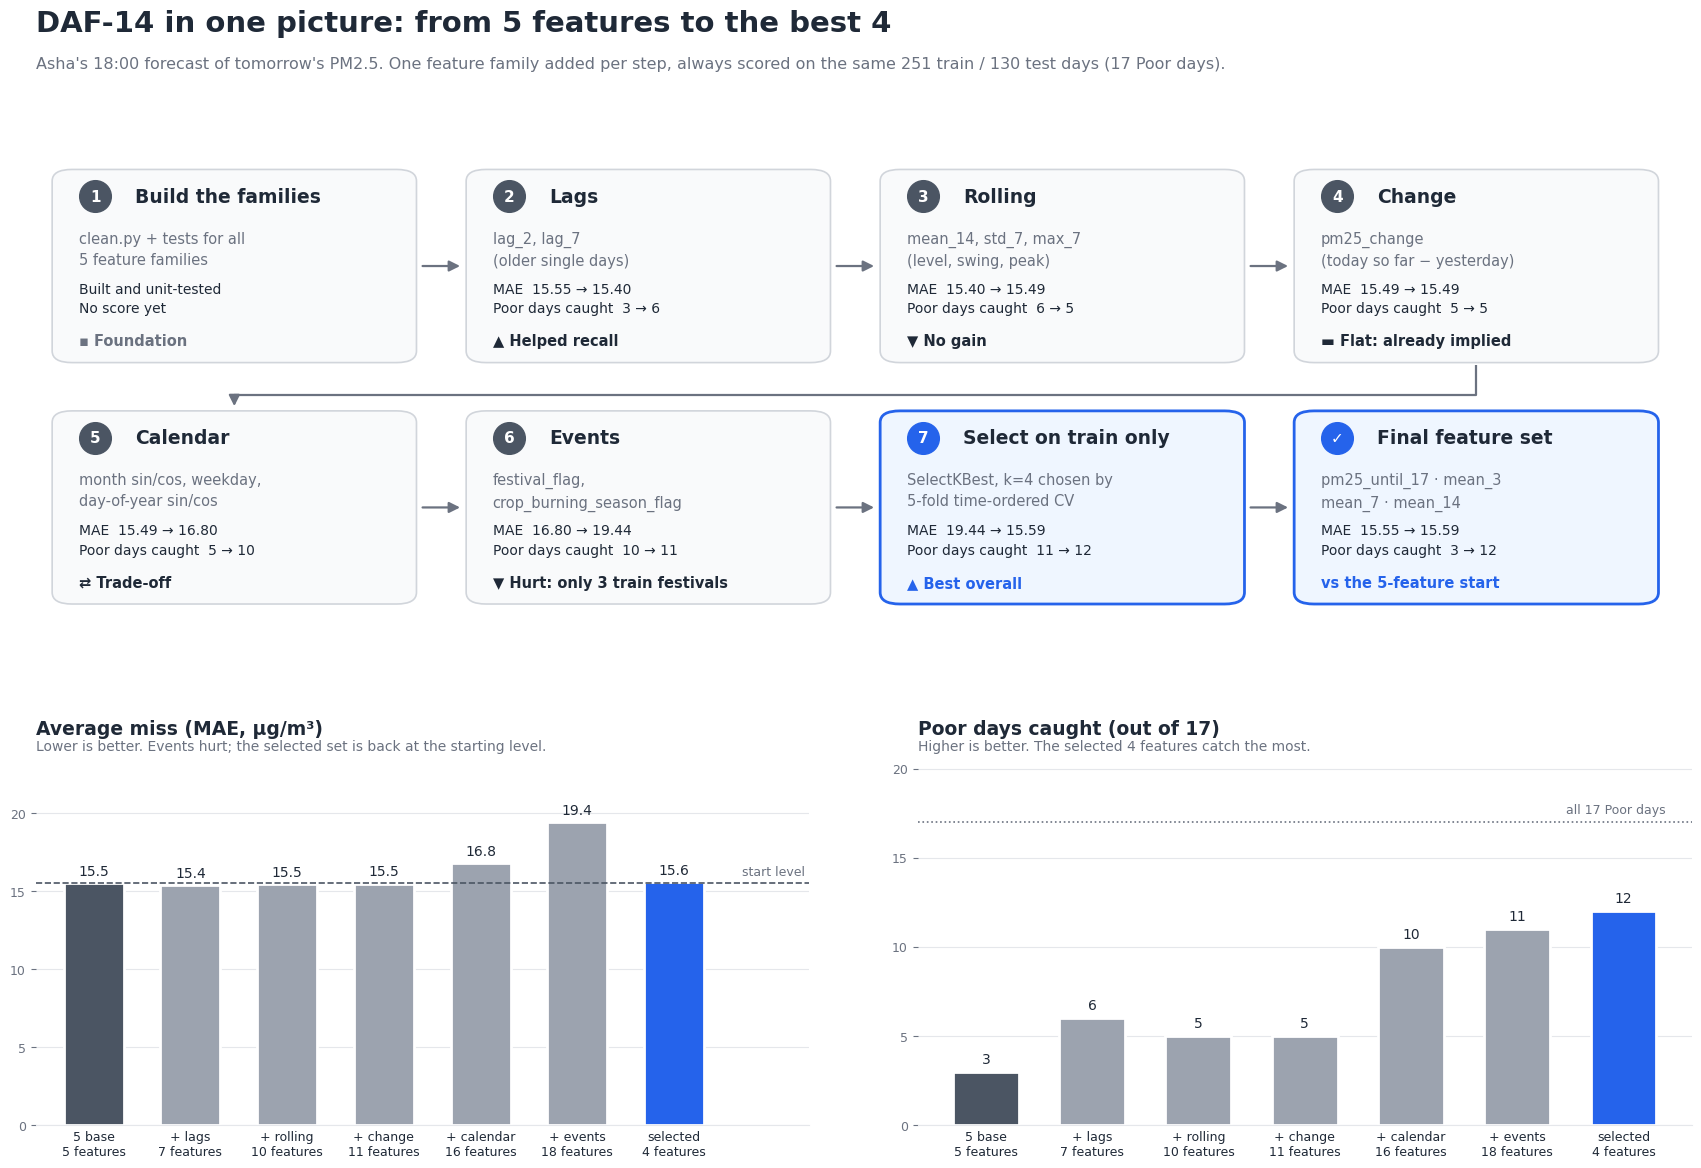

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import MultipleLocator

# Continues from Steps 6 and 7: same train/test rows, same fit_and_score, same selected_features.
calendar_columns = ["month_sin", "month_cos", "day_of_week", "day_of_year_sin", "day_of_year_cos"]
event_columns = ["festival_flag", "crop_burning_season_flag"]

recap_sets = {
    "base": daf13_features,
    "lags": daf13_features + ["lag_2", "lag_7"],
}
recap_sets["rolling"] = recap_sets["lags"] + ["mean_14", "std_7", "max_7"]
recap_sets["change"] = recap_sets["rolling"] + ["pm25_change"]
recap_sets["calendar"] = recap_sets["change"] + calendar_columns
recap_sets["events"] = recap_sets["calendar"] + event_columns
recap_sets["selected"] = selected_features

n_poor = int((test["target"] >= poor_threshold).sum())
recap = {}
for name, columns in recap_sets.items():
    result = fit_and_score(columns, name)
    recap[name] = {
        "mae": result["mae"],
        "caught": round(result["recall_poor"] * n_poor),
        "n_features": len(columns),
    }

INK, MUTED, GRID = "#1f2937", "#6b7280", "#e5e7eb"
BAR, BASE_BAR, ACCENT = "#9ca3af", "#4b5563", "#2563eb"
CARD_EDGE, CARD_FILL = "#d1d5db", "#f9fafb"

fig = plt.figure(figsize=(18, 12.5), facecolor="white")
grid = fig.add_gridspec(2, 2, height_ratios=[1.35, 1], hspace=0.32, wspace=0.14, left=0.05, right=0.97, top=0.86, bottom=0.08)
flow = fig.add_subplot(grid[0, :])
flow.set_xlim(0, 100)
flow.set_ylim(0, 50)
flow.axis("off")

fig.text(0.05, 0.955, "DAF-14 in one picture: from 5 features to the best 4", fontsize=21, fontweight="bold", color=INK)
fig.text(
    0.05, 0.925,
    "Asha's 18:00 forecast of tomorrow's PM2.5. One feature family added per step, always scored on the same "
    f"{len(train)} train / {len(test)} test days ({n_poor} Poor days).",
    fontsize=11.5, color=MUTED,
)


def delta_line(before, after):
    a, b = recap[before], recap[after]
    return f"MAE  {a['mae']:.2f} → {b['mae']:.2f}\nPoor days caught  {a['caught']} → {b['caught']}"


cards = [
    ("1", "Build the families", "clean.py + tests for all\n5 feature families", "Built and unit-tested\nNo score yet", "▪ Foundation", MUTED),
    ("2", "Lags", "lag_2, lag_7\n(older single days)", delta_line("base", "lags"), "▲ Helped recall", INK),
    ("3", "Rolling", "mean_14, std_7, max_7\n(level, swing, peak)", delta_line("lags", "rolling"), "▼ No gain", INK),
    ("4", "Change", "pm25_change\n(today so far − yesterday)", delta_line("rolling", "change"), "▬ Flat: already implied", INK),
    ("5", "Calendar", "month sin/cos, weekday,\nday-of-year sin/cos", delta_line("change", "calendar"), "⇄ Trade-off", INK),
    ("6", "Events", "festival_flag,\ncrop_burning_season_flag", delta_line("calendar", "events"), "▼ Hurt: only 3 train festivals", INK),
    ("7", "Select on train only", "SelectKBest, k=4 chosen by\n5-fold time-ordered CV", delta_line("events", "selected"), "▲ Best overall", ACCENT),
    ("✓", "Final feature set", "pm25_until_17 · mean_3\nmean_7 · mean_14", delta_line("base", "selected"), "vs the 5-feature start", ACCENT),
]
card_w, card_h = 22, 20
xs = [1, 26, 51, 76]
rows_y = [28, 3]
for index, (badge, title, adds, numbers, verdict, verdict_color) in enumerate(cards):
    x, y = xs[index % 4], rows_y[index // 4]
    final = index >= 6
    flow.add_patch(
        FancyBboxPatch(
            (x, y), card_w, card_h, boxstyle="round,pad=0.0,rounding_size=1.2",
            facecolor="#eff6ff" if final else CARD_FILL,
            edgecolor=ACCENT if final else CARD_EDGE, linewidth=2.0 if final else 1.2,
        )
    )
    flow.scatter([x + 2.6], [y + card_h - 2.8], s=520, color=ACCENT if final else BASE_BAR, zorder=3)
    flow.text(x + 2.6, y + card_h - 2.8, badge, ha="center", va="center", fontsize=11, fontweight="bold", color="white", zorder=4)
    flow.text(x + 5.0, y + card_h - 2.8, title, ha="left", va="center", fontsize=13.5, fontweight="bold", color=INK)
    flow.text(x + 1.6, y + card_h - 6.4, adds, ha="left", va="top", fontsize=10.5, color=MUTED, linespacing=1.5)
    flow.text(x + 1.6, y + 6.6, numbers, ha="left", va="center", fontsize=10, color=INK, linespacing=1.5)
    flow.text(x + 1.6, y + 2.2, verdict, ha="left", va="center", fontsize=10.5, fontweight="bold", color=verdict_color)

arrow_style = dict(arrowstyle="-|>", color=MUTED, lw=1.6, mutation_scale=16)
for row_y in rows_y:
    for col in range(3):
        start = xs[col] + card_w + 0.2
        flow.annotate("", xy=(xs[col + 1] - 0.2, row_y + card_h / 2), xytext=(start, row_y + card_h / 2), arrowprops=arrow_style)
flow.plot([xs[3] + card_w / 2, xs[3] + card_w / 2, xs[0] + card_w / 2], [rows_y[0] - 0.2, 24.6, 24.6], color=MUTED, lw=1.6, solid_capstyle="butt")
flow.annotate("", xy=(xs[0] + card_w / 2, rows_y[1] + card_h + 0.2), xytext=(xs[0] + card_w / 2, 24.6), arrowprops=arrow_style)

labels = ["5 base", "+ lags", "+ rolling", "+ change", "+ calendar", "+ events", "selected"]
keys = list(recap_sets)
counts = [recap[k]["n_features"] for k in keys]
tick_labels = [f"{label}\n{count} features" for label, count in zip(labels, counts)]
colors = [BASE_BAR] + [BAR] * 5 + [ACCENT]


def style_axis(ax, title, subtitle):
    ax.set_title(title, loc="left", fontsize=13.5, fontweight="bold", color=INK, pad=24)
    ax.text(0, 1.04, subtitle, transform=ax.transAxes, fontsize=10, color=MUTED, va="bottom")
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(axis="x", length=0, labelsize=9, colors=INK)
    ax.tick_params(axis="y", labelsize=9, colors=MUTED)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)


mae_ax = fig.add_subplot(grid[1, 0])
mae_values = [recap[k]["mae"] for k in keys]
mae_bars = mae_ax.bar(range(7), mae_values, width=0.62, color=colors, edgecolor="white", linewidth=2)
mae_ax.axhline(mae_values[0], color=BASE_BAR, linestyle="--", linewidth=1.2)
mae_ax.text(7.35, mae_values[0] + 0.3, "start level", ha="right", va="bottom", fontsize=9, color=MUTED)
mae_ax.set_xlim(-0.6, 7.4)
for bar, value in zip(mae_bars, mae_values):
    mae_ax.text(bar.get_x() + bar.get_width() / 2, value + 0.3, f"{value:.1f}", ha="center", va="bottom", fontsize=10, color=INK)
mae_ax.set_xticks(range(7), tick_labels)
mae_ax.set_ylim(0, max(mae_values) * 1.18)
style_axis(mae_ax, "Average miss (MAE, µg/m³)", "Lower is better. Events hurt; the selected set is back at the starting level.")

caught_ax = fig.add_subplot(grid[1, 1])
caught_values = [recap[k]["caught"] for k in keys]
caught_bars = caught_ax.bar(range(7), caught_values, width=0.62, color=colors, edgecolor="white", linewidth=2)
caught_ax.axhline(n_poor, color=MUTED, linestyle=":", linewidth=1.2)
caught_ax.text(6.4, n_poor + 0.3, f"all {n_poor} Poor days", ha="right", va="bottom", fontsize=9, color=MUTED)
for bar, value in zip(caught_bars, caught_values):
    caught_ax.text(bar.get_x() + bar.get_width() / 2, value + 0.3, str(value), ha="center", va="bottom", fontsize=10, color=INK)
caught_ax.set_xticks(range(7), tick_labels)
caught_ax.set_ylim(0, n_poor * 1.18)
caught_ax.yaxis.set_major_locator(MultipleLocator(5))
style_axis(caught_ax, f"Poor days caught (out of {n_poor})", "Higher is better. The selected 4 features catch the most.")

plt.show()

### Recap in five lines

1. **Lags** helped Poor-day recall a little, and `lag_1` was already in the start set.
2. **Rolling** and **change** added nothing new: the model could already work them out from what it had.
3. **Calendar** caught more Poor days but made average error worse.
4. **Events** made average error worse: only three festival days in training, and one Holi test day predicted far too high.
5. **Selection on training rows only** kept four level features and beat the 18-feature set on both measures.

**If you remember only one thing:** adding features is not the same as adding information. Add one family at a time, score it on the same days, and let train-only selection decide what stays.